# 01 — EDA: Spotify Tracks Dataset

**TCC · Sistemas de Informação · UFJF**

Exploração da base [Spotify Tracks Dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset).

Este notebook é a **fonte** do visualizador estático em `docs/index.html`.
O HTML já está pré-renderizado — o orientador não precisa executar nada.

## 1. Carregamento e limpeza básica

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

# Caminho relativo à pasta data/ do repositório
# Baixe o CSV do Kaggle ou Hugging Face e coloque em data/dataset.csv
DATA_PATH = '../data/dataset.csv'

df = pd.read_csv(DATA_PATH)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print('Shape original:', df.shape)
df = df.drop_duplicates(subset=['track_id'])
print('Shape após deduplicar track_id:', df.shape)
df.head()

Shape original: (114000, 20)
Shape após deduplicar track_id: (89741, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 2. Visão geral

In [2]:
print('Gêneros únicos:', df['track_genre'].nunique())
print('Artistas (combinações) únicos:', df['artists'].nunique())
print('\nValores faltantes:\n', df.isnull().sum()[df.isnull().sum() > 0])
print('\n% explicit:', round(100 * df['explicit'].mean(), 1))

Gêneros únicos: 113
Artistas (combinações) únicos: 31437

Valores faltantes:
 artists       1
album_name    1
track_name    1
dtype: int64

% explicit: 8.6


## 3. Distribuição de gêneros (Top 20)

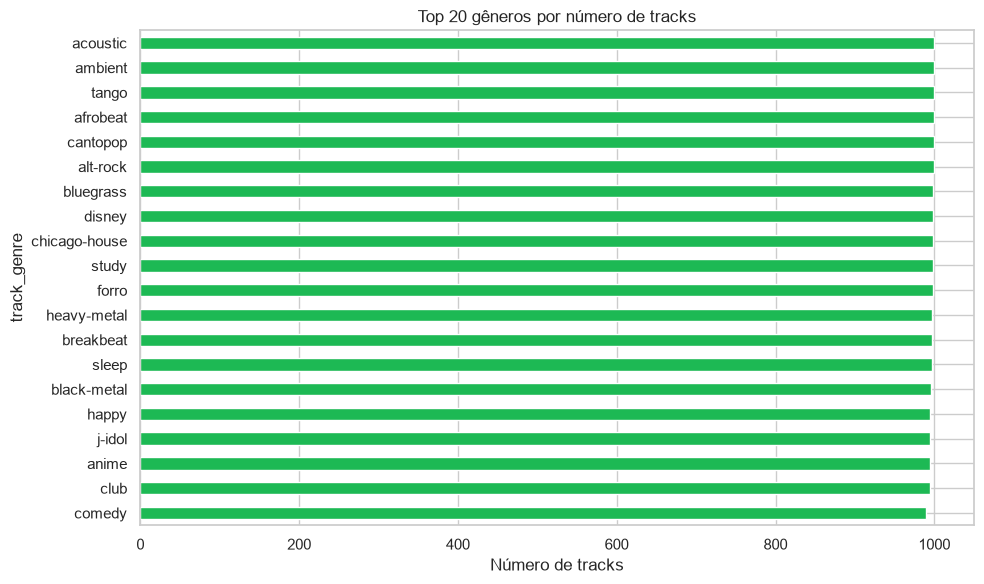

In [3]:
genre_counts = df['track_genre'].value_counts()
fig, ax = plt.subplots(figsize=(10, 6))
genre_counts.head(20).sort_values().plot(kind='barh', ax=ax, color='#1DB954')
ax.set_title('Top 20 gêneros por número de tracks')
ax.set_xlabel('Número de tracks')
plt.tight_layout()
fig.savefig('../docs/assets/fig1.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Distribuições das audio features

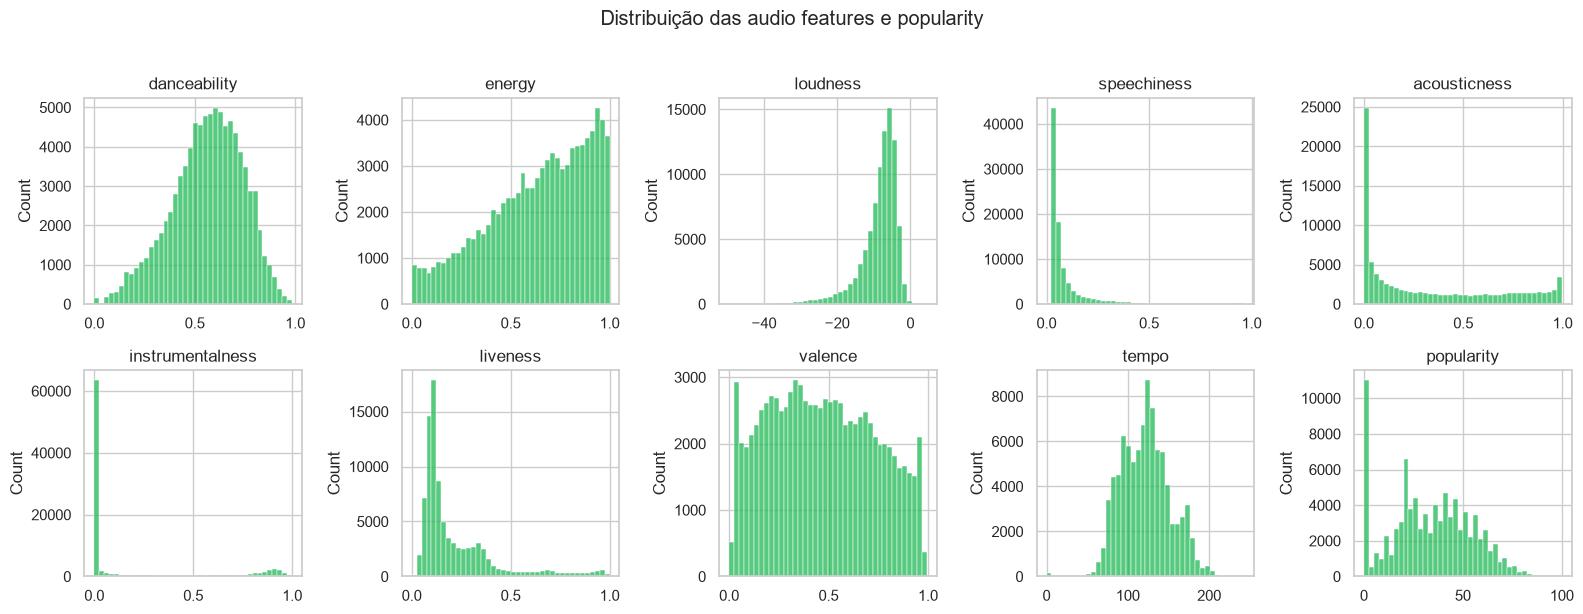

In [4]:
audio_features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'popularity'
]

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.flatten()
for i, col in enumerate(audio_features):
    sns.histplot(df[col].dropna(), bins=40, ax=axes[i], color='#1DB954')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
fig.suptitle('Distribuição das audio features e popularity', y=1.02)
plt.tight_layout()
fig.savefig('../docs/assets/fig2.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Matriz de correlação

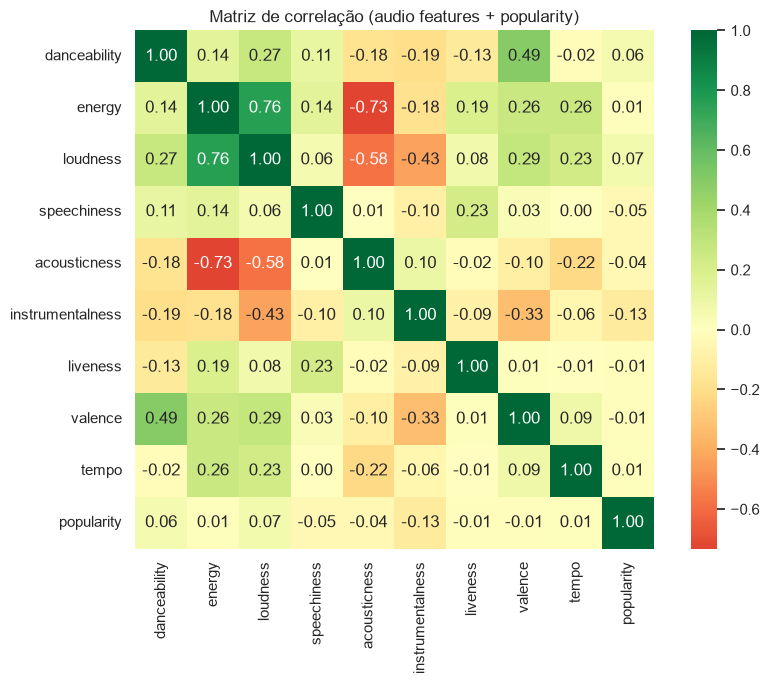

In [5]:
corr = df[audio_features].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax, square=True)
ax.set_title('Matriz de correlação (audio features + popularity)')
plt.tight_layout()
fig.savefig('../docs/assets/fig3.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Popularity × energy / valence / danceability

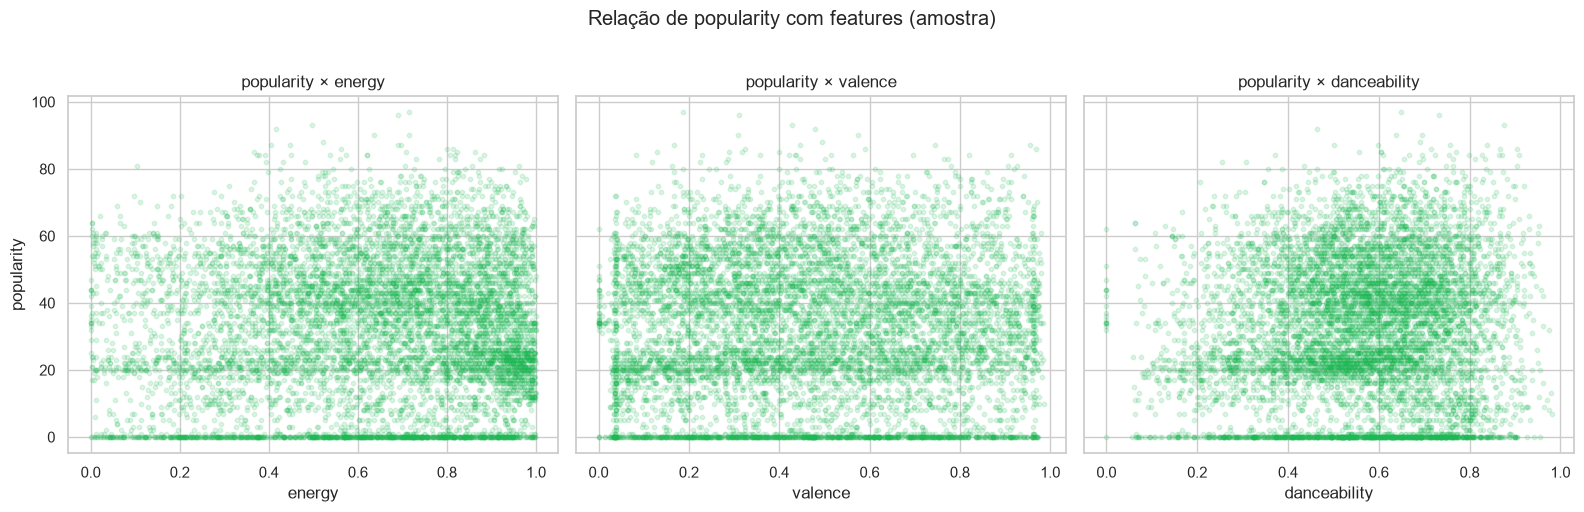

In [6]:
sample = df.sample(n=8000, random_state=42)

scatter_features = ['energy', 'valence', 'danceability']
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for i, feat in enumerate(scatter_features):
    axes[i].scatter(sample[feat], sample['popularity'],
                    alpha=0.15, s=10, color='#1DB954')
    axes[i].set_title(f'popularity × {feat}')
    axes[i].set_xlabel(feat)
    if i == 0:
        axes[i].set_ylabel('popularity')

fig.suptitle('Relação de popularity com features (amostra)', y=1.02)
plt.tight_layout()
fig.savefig('../docs/assets/fig4.jpg', dpi=150, bbox_inches='tight')
plt.show()

## 7. Popularity por gênero (Top 12)

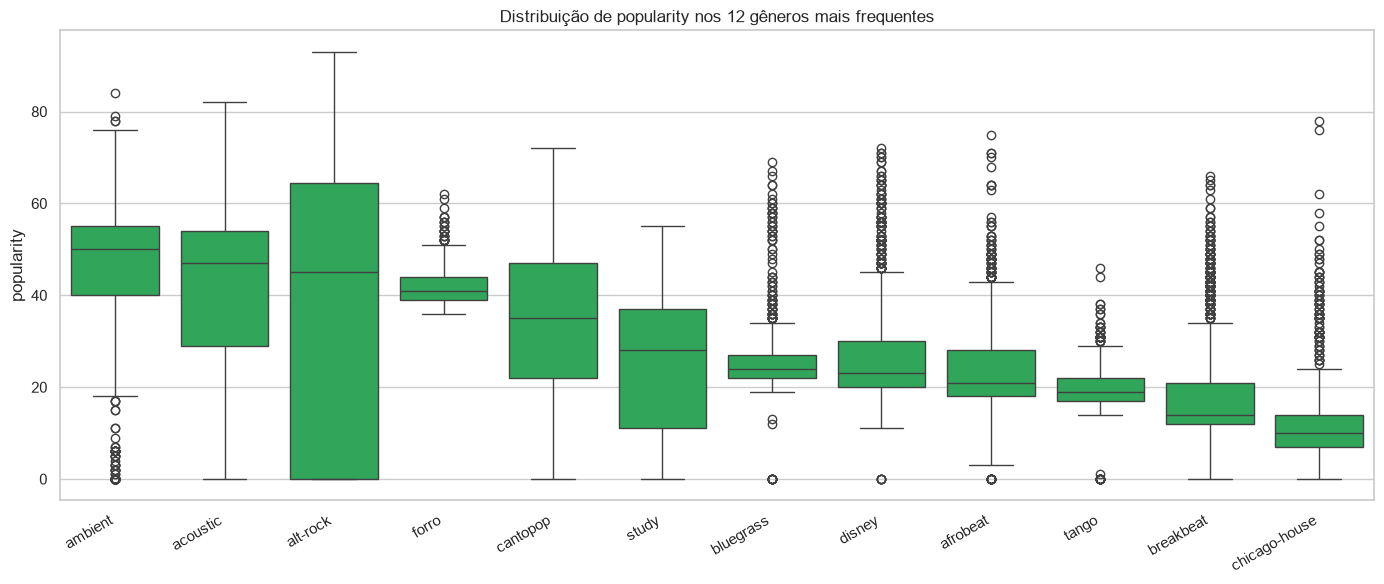

In [7]:
top_genres = df['track_genre'].value_counts().head(12).index
df_top = df[df['track_genre'].isin(top_genres)]

# Ordenar gêneros pela mediana de popularity (decrescente)
genre_order = (df_top.groupby('track_genre')['popularity']
               .median().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df_top, x='track_genre', y='popularity',
            order=genre_order, color='#1DB954', ax=ax)
ax.set_title('Distribuição de popularity nos 12 gêneros mais frequentes')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
fig.savefig('../docs/assets/fig5.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Observações para o TCC

- A base é adequada para recomendação **content-based** (audio features).
- `popularity` é score do Spotify, não feedback de usuário.
- A base é estratificada por gênero (~1000 tracks por gênero), o que facilita análises por gênero sem necessidade de balanceamento.
- Não há interações usuário–item → avaliação de ranking precisará de estratégia alternativa.
- Features como `instrumentalness` e `speechiness` são fortemente assimétricas (concentradas próximas de 0) — importante para normalização e escolha de métrica de distância.